In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

In [80]:
np.random.seed(42)
n_samples = 100
X1 = np.random.rand(n_samples) * 10  # Feature 1
X2 = np.random.rand(n_samples) * 20  # Feature 2
X3 = np.random.rand(n_samples) * 5   # Feature 3
noise = np.random.randn(n_samples) * 2
y = 3*X1 + 2*X2 - 1*X3 + noise
df = pd.DataFrame({'Feature1': X1,'Feature2': X2,'Feature3': X3,'Target': y})
print(df.head())

   Feature1   Feature2  Feature3     Target
0  3.745401   0.628584  3.210158   9.374356
1  9.507143  12.728208  0.420700  52.253945
2  7.319939   6.287120  0.808144  38.013802
3  5.986585  10.171414  4.492771  35.077649
4  1.560186  18.151329  3.032145  33.900788


## Linear Relationship
The relationship between input (features) and output (target) should be approximately linear.

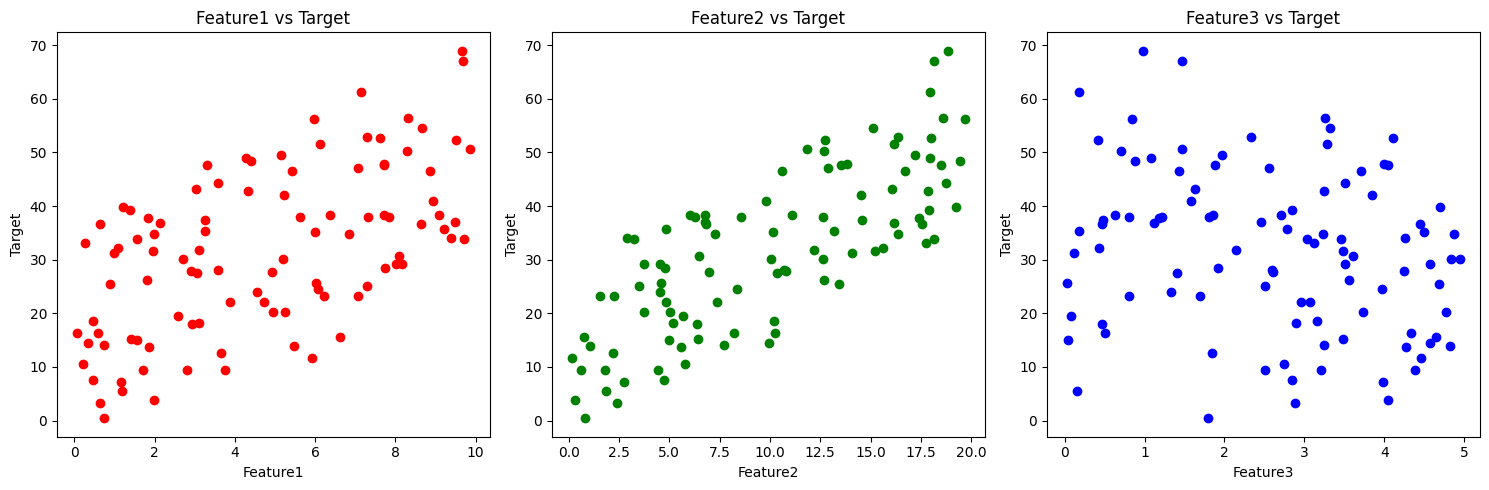

In [81]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns
ax1.scatter(df['Feature1'], df['Target'], color='r')
ax1.set_xlabel('Feature1')
ax1.set_ylabel('Target')
ax1.set_title('Feature1 vs Target')

ax2.scatter(df['Feature2'], df['Target'], color='g')
ax2.set_xlabel('Feature2')
ax2.set_ylabel('Target')
ax2.set_title('Feature2 vs Target')

ax3.scatter(df['Feature3'], df['Target'], color='b')
ax3.set_xlabel('Feature3')
ax3.set_ylabel('Target')
ax3.set_title('Feature3 vs Target')

plt.tight_layout()
plt.show()

## No Multicollinearity
Features should not be highly correlated with each other; otherwise, it’s hard to estimate coefficients accurately.

<Axes: >

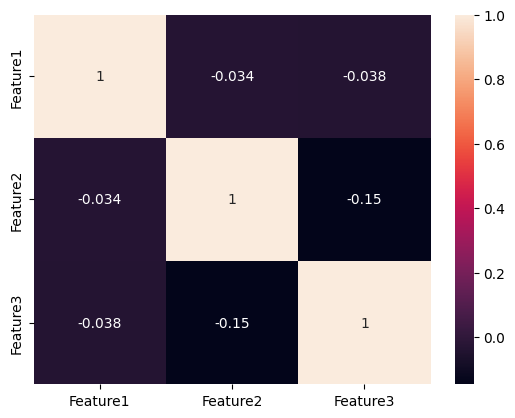

In [82]:
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

In [83]:
X=df[['Feature1','Feature2','Feature3']]
y=df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:
y_pred=model.predict(X_test)
residuals=y_test-y_pred

## Normality of Residuals
The residuals (errors) should be normally distributed. Q-Q plots or histograms are commonly used to check this.

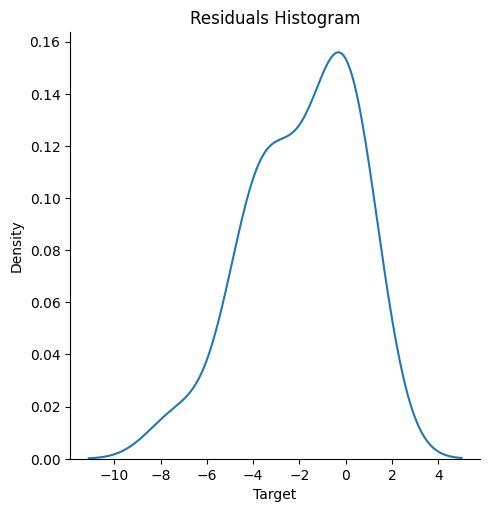

In [86]:
sns.displot(residuals, kind='kde')
plt.title("Residuals Histogram")
plt.show()

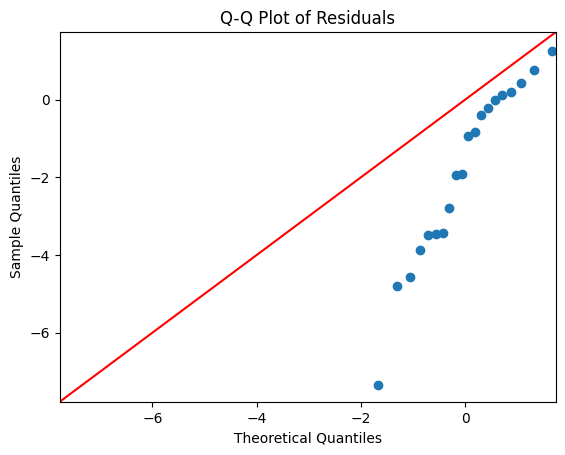

In [87]:
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

## Homoscedasticity 
The variance of residuals should be constant across all levels of predicted values. Residual vs predicted plots can detect heteroscedasticity.

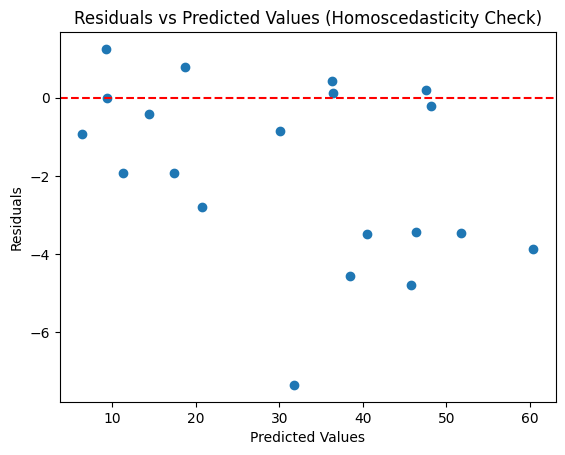

In [88]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values (Homoscedasticity Check)")
plt.show()

## No Autocorrelation of Errors
Residuals should not be correlated with each other, which is especially important in time series data.

<Axes: ylabel='Target'>

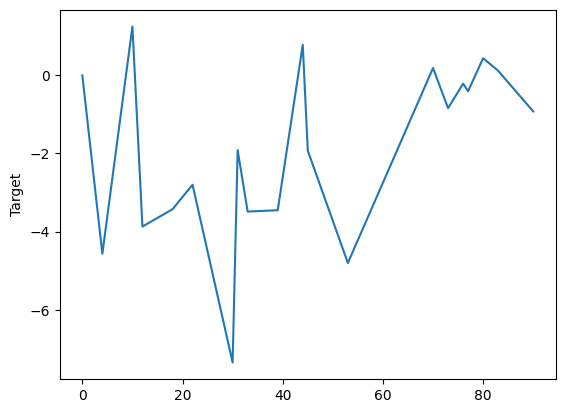

In [89]:
sns.lineplot(residuals)

In [90]:
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")
if dw_stat < 1.5:
    print("Some positive autocorrelation may be present.")
elif dw_stat > 2.5:
    print("Some negative autocorrelation may be present.")
else:
    print("Residuals show no significant autocorrelation.")

Durbin-Watson statistic: 1.324
Some positive autocorrelation may be present.
